# Report

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
import rasterio
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xarray as xr

**Load datasets**

This study uses multiple datasets from reliable scientific and governmental sources. Weather data were obtained from the Royal Netherlands Meteorological Institute (KNMI), including measurements such as temperature, wind, precipitation, and radiation from several coastal stations in the Netherlands. Environmental data were sourced from Statistics Netherlands (CBS), specifically ecosystem type maps covering the period 2013–2022. In addition, species occurrence data for Clupea harengus (Atlantic herring) were retrieved from the Global Biodiversity Information Facility (GBIF), an international open-access biodiversity database.

In [192]:
df_clupea = pd.read_csv('Clupea harengus.csv', low_memory=False)
df_weather = pd.read_csv('knmi_weather_data.csv')
df_env = pd.read_csv('habitats_cbs_2022.csv')
ds = xr.open_dataset('water_temp_salt.nc', engine="netcdf4")
# print(ds.data_vars)
# print(ds)

df_water = ds.to_dataframe().reset_index()

# print(df_water.isna().sum())
# print(len(df_water))

column_mapping = {
    "time": "date",
    "latitude": "latitude",
    "longitude": "longitude",
    "mlotst": "mixed_layer_thickness",
    "thetao": "sea_water_temperature",
    "ubar": "eastward_depth_averaged_current",
    "vbar": "northward_depth_averaged_current",
    "uo": "eastward_ocean_current",
    "vo": "northward_ocean_current",
    "zos": "sea_surface_height"
}

df_water = df_water.rename(columns=column_mapping).copy()


In [193]:
df_clupea['eventDate'] = pd.to_datetime(df_clupea['eventDate'], format='%Y-%m-%d')
df_clupea['Clupea harengus'] = pd.to_numeric(df_clupea['Clupea harengus'], errors='coerce')
print("General information:")
df_clupea.info()

print("\n\nAmount of null's in each column:")
print(df_clupea.isnull().sum())

print("\n\nStatistical summary:")
df_water.describe()

print("\n\nAmount of null's in each column (water dataset):")
print(df_clupea.isnull().sum())

print("\n\nStatistical summary (water dataset):")
df_water.describe()

df_water_filtered = df_water[
    df_water["longitude"].between(3, 7) &
    df_water["latitude"].between(51, 53.5)
].copy()

len(df_water_filtered)

df_water_filtered = df_water_filtered.rename(columns={
    "longitude": "decimalLongitude",
    "latitude": "decimalLatitude"
})


df_water_filtered = df_water_filtered[["decimalLongitude", "decimalLatitude", "sea_water_temperature", "date"]].dropna(subset=["sea_water_temperature"]).reset_index(drop=True)

daily_temp = (
    df_water_filtered
        .groupby(df_water_filtered['date'].dt.date)['sea_water_temperature']
        .mean().round(2)
        .reset_index()
        .rename(columns={'date': 'eventDate',
                         'sea_water_temperature': 'mean_sea_water_temperature'})
)
daily_temp.head(10)


General information:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Clupea harengus            float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 574.9 MB


Amount of null's in each column:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Clupea harengus              4
dtype: int64


Statistical summary:


Amount of null's in each column (water dataset):
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations          

,eventDate,mean_sea_water_temperature
0,2022-11-23,11.95
1,2022-11-24,11.81
2,2022-11-25,11.72
3,2022-11-26,11.63
4,2022-11-27,11.46
5,2022-11-28,11.42
6,2022-11-29,11.38
7,2022-11-30,11.36
8,2022-12-01,11.23
9,2022-12-02,11.01


In [194]:
str_columns = df_weather.select_dtypes(include=['object', 'string']).columns

for col in str_columns:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')

df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%Y%m%d')

df_weather = df_weather.replace(r'^\s*$', pd.NA, regex=True)

print("General information:")
df_weather.info()

print("\n\nAmount of null's in each column:")
print(df_weather.isna().sum())

print("\n\nStatistical summary:")
df_weather.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  70421 non-null  float64       
 3   vector_mean_windspeed          70421 non-null  float64       
 4   windspeed                      70514 non-null  float64       
 5   windgust                       70498 non-null  float64       
 6   temp_mean                      35855 non-null  float64       
 7   temp_min                       35855 non-null  float64       
 8   temp_max                       35855 non-null  float64       
 9   sun_dur                        29906 non-null  float64       
 10  per_max_pot_sun_dur            29906 non-null  float64       
 11  globa

,Station,Date,vector_mean_direction_degrees,vector_mean_windspeed,windspeed,windgust,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover
count,71784.000000,71784,70421.000000,70421.000000,70514.000000,70498.000000,35855.000000,35855.000000,35855.000000,29906.000000,29906.000000,29906.000000,29907.000000,29907.000000,19291.000000
mean,274.750000,2018-03-10 12:00:00,190.671490,59.356769,67.406132,132.244319,109.198857,80.477925,137.794338,53.724069,41.440012,1107.955527,17.106697,22.103454,5.686693
min,209.000000,2010-01-01 00:00:00,1.000000,0.000000,10.000000,30.000000,-114.000000,-176.000000,-67.000000,-1.000000,0.000000,22.000000,0.000000,-1.000000,0.000000
25%,240.250000,2014-02-04 00:00:00,110.000000,36.000000,45.000000,100.000000,67.000000,42.000000,89.000000,14.000000,13.000000,337.250000,0.000000,0.000000,4.000000
50%,281.000000,2018-03-10 12:00:00,210.000000,56.000000,63.000000,120.000000,106.000000,79.000000,135.000000,48.000000,40.000000,935.000000,2.000000,1.000000,6.000000
75%,310.500000,2022-04-14 00:00:00,258.000000,79.000000,85.000000,160.000000,156.000000,125.000000,188.000000,87.000000,68.000000,1770.000000,24.000000,24.000000,8.000000
max,330.000000,2026-05-18 00:00:00,360.000000,202.000000,203.000000,480.000000,303.000000,236.000000,389.000000,157.000000,95.000000,3180.000000,240.000000,780.000000,8.000000
std,39.132793,NaN,95.306002,30.438256,28.593083,47.734481,57.372641,54.645667,64.412893,43.248569,30.372459,838.851918,28.085692,45.114325,2.241838


| Station | LON (east) | LAT (north) | ALT (m) | Name               |
| ------- | ---------- | ----------- | ------- | ------------------ |
| 209     | 4.518      | 52.465      | 0.00    | IJmond             |
| 225     | 4.555      | 52.463      | 4.40    | IJmuiden           |
| 235     | 4.781      | 52.928      | 1.20    | De Kooy Airport    |
| 242     | 4.921      | 53.241      | 10.80   | Vlieland Vliehors  |
| 251     | 5.346      | 53.392      | 0.70    | Hoorn Terschelling |
| 277     | 6.200      | 53.413      | 2.90    | Lauwersoog         |
| 285     | 6.399      | 53.575      | 0.00    | Huibertgat         |
| 308     | 3.379      | 51.381      | 0.00    | Cadzand            |
| 310     | 3.596      | 51.442      | 8.00    | Vlissingen         |
| 312     | 3.622      | 51.768      | 0.00    | Oosterschelde      |
| 313     | 3.242      | 51.505      | 0.00    | Vlakte van De Raan |
| 330     | 4.122      | 51.992      | 11.90   | Hoek van Holland   |

In [195]:
# 1. Ensure daily_temp eventDate is datetime64 (no time)
daily_temp['eventDate'] = pd.to_datetime(daily_temp['eventDate'])

# (Optional but often nice: normalize to midnight so all times are 00:00:00)
daily_temp['eventDate'] = daily_temp['eventDate'].dt.normalize()

# 2. Also normalize df_weather['Date'] so both are datetime64[ns] with no time component
df_weather['Date'] = df_weather['Date'].dt.normalize()

# 3. Merge
df_weather = df_weather.merge(
    daily_temp,
    left_on='Date',
    right_on='eventDate',
    how='left',
    validate='many_to_one'
)

# 4. Optional: drop duplicate key
df_weather = df_weather.drop(columns=['eventDate'])

In [196]:
df_weather = df_weather.ffill()
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  71784 non-null  float64       
 3   vector_mean_windspeed          71784 non-null  float64       
 4   windspeed                      71784 non-null  float64       
 5   windgust                       71784 non-null  float64       
 6   temp_mean                      71784 non-null  float64       
 7   temp_min                       71784 non-null  float64       
 8   temp_max                       71784 non-null  float64       
 9   sun_dur                        71784 non-null  float64       
 10  per_max_pot_sun_dur            71784 non-null  float64       
 11  global_radiation          

---

## 1. Business Understanding (The Ecology / Project Goal)
In an academic data science project using the herring habitat dataset, "business understanding" translates to your ecological objective. 
- **Background:** Briefly explain why modeling the habitat of *Clupea harengus* matters (e.g., understanding spawning grounds, tracking population shifts due to environment, etc.).
- **Problem Statement:** What question are you answering? For example: *"Can we predict the presence or abundance of Atlantic herring based on the percentage of different habitat types (e.g., coastal, water, agricultural) in a given area?"* [exxactcorp](https://www.exxactcorp.com/blog/deep-learning/simple-steps-for-data-preparation-exploratory-data-analysis)
- **Data Management Goals (DMGs):** This is the technical translation of your problem. What exact modeling task will you perform? State whether it is a classification task (e.g., predicting presence vs. absence) or a regression task (e.g., predicting observation counts). Define your target variable and your predictor variables.
- **Success Criteria:** How will you know if your model is "good"? Define the metric you will use (e.g., "Achieve an F1-score above 0.70" or "Beat a baseline logistic regression model by 15% accuracy"). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)

## 2. Initial Exploratory Data Analysis (EDA)
EDA is how you prove you have inspected the data before blindly throwing algorithms at it. You do not need perfect, highly-polished charts yet; the goal is to show you understand the dataset's shape, quality, and patterns. [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)

Include the following steps and visuals in your EDA:
- **Data Overview:** Report the shape of your dataset (number of rows and columns) and list the features (e.g., `decimalLongitude`, `decimalLatitude`, `coast`, `forest`, `agricultural`, etc.). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)
- **Data Quality Check:** Show that you have checked for missing values (NaNs), duplicates, and incorrect data types. Mention how you plan to handle any issues you found (e.g., "We will drop 12 rows with missing coordinates"). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
- **Univariate Analysis (Distributions):** Look at variables one at a time.
  - Plot a histogram or bar chart of your target variable. Is it imbalanced? (e.g., Are there 10,000 "presence" rows but only 500 "absence" rows?)
  - Plot histograms for key predictors (like the percentage of `coast` or `water` habitat). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Bivariate/Multivariate Analysis (Relationships):** Look at how variables interact.
  - Show a correlation heatmap of the numerical features. This will show if variables are highly correlated (e.g., maybe `coast` and `water` are multicollinear and you shouldn't use both). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
  - Create boxplots or violin plots showing the distribution of specific habitat types split by your target variable (e.g., "Percentage of Coastal Habitat vs. Herring Presence"). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Spatial Plot (Optional but highly recommended):** Since you have coordinates (`decimalLongitude`, `decimalLatitude`), plot your data points on a scatter plot or a map. This is a massive bonus for an ecological dataset and immediately shows if herring are clustering in specific regions.

Finish your check-in with a short **conclusion/next steps** section stating your data is viable and what preprocessing (scaling, imputation, feature engineering) you will do next based on your EDA. 

---

### Data Understanding

In [197]:
# Merge environmental data
df_merged = pd.merge(
    df_clupea,
    df_env,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left'
)

# Aggregate weather by day first
weather_daily = df_weather.groupby('Date').mean(numeric_only=True).reset_index()

stations = pd.DataFrame({
    'Station': [209, 225, 235, 242, 251, 277, 285, 308, 310, 312, 313, 330],
    'LON':     [4.518, 4.555, 4.781, 4.921, 5.346, 6.200, 6.399, 3.379, 3.596, 3.622, 3.242, 4.122],
    'LAT':     [52.465, 52.463, 52.928, 53.241, 53.392, 53.413, 53.575, 51.381, 51.442, 51.768, 51.505, 51.992]
})

grids = df_merged[['decimalLatitude', 'decimalLongitude']].drop_duplicates().copy()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def nearest_station(lat, lon, stations_df):
    dists = haversine(lat, lon, stations_df['LAT'].values, stations_df['LON'].values)
    idx = np.argmin(dists)
    return pd.Series({
        'nearest_station': stations_df.iloc[idx]['Station'],
        'station_distance_km': dists[idx]
    })

grids[['nearest_station', 'station_distance_km']] = (
    grids.apply(lambda row: nearest_station(row['decimalLatitude'], row['decimalLongitude'], stations), axis=1)
)

df_merged = df_merged.merge(
    grids,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left',
    validate='many_to_one'
)

df_merged = df_merged.merge(
    df_weather,
    left_on=['nearest_station', 'eventDate'],
    right_on=['Station', 'Date'],
    how='left',
    validate='many_to_one'
)


df_merged_to = df_merged[df_merged['total_observations'].fillna(0) != 0]
df_merged_so = df_merged[df_merged['speciesgroup_observations'].fillna(0) != 0]
df_merged_ch = df_merged[df_merged['Clupea harengus'].fillna(0) != 0]

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 33 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   decimalLatitude                float64       
 1   decimalLongitude               float64       
 2   eventDate                      datetime64[us]
 3   total_observations             float64       
 4   speciesgroup_observations      int64         
 5   Clupea harengus                float64       
 6   agricultural                   float64       
 7   built                          float64       
 8   coast                          float64       
 9   forest                         float64       
 10  other                          float64       
 11  sand/heather                   float64       
 12  water                          float64       
 13  wetland                        float64       
 14  main_habitat                   str           
 15  nearest_station         

In [198]:
df_merged.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Clupea harengus,agricultural,built,coast,forest,...,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover,mean_sea_water_temperature
0,50.75,5.65,2010-01-01,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,6.0,-15.0,19.0,66.0,83.0,455.0,0.0,0.0,3.0,7.12
1,50.75,5.65,2010-01-02,26.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,12.0,-4.0,22.0,18.0,23.0,229.0,56.0,47.0,7.0,7.12
2,50.75,5.65,2010-01-03,3.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,-15.0,-29.0,21.0,70.0,88.0,476.0,19.0,15.0,2.0,7.12
3,50.75,5.65,2010-01-04,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,-4.0,-34.0,37.0,12.0,15.0,224.0,8.0,2.0,7.0,7.12
4,50.75,5.65,2010-01-05,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,5.0,-14.0,29.0,42.0,52.0,294.0,0.0,0.0,6.0,7.12


In [199]:
cond_south = (df_merged['decimalLatitude'] < 51.8) & (df_merged['decimalLongitude'] <= 4.25)

cond_mid = (df_merged['decimalLatitude'] >= 51.8) & (df_merged['decimalLatitude'] < 52.8) & \
           (df_merged['decimalLongitude'] <= (4.2 + (df_merged['decimalLatitude'] - 51.8) * 0.7))

cond_north = (df_merged['decimalLatitude'] >= 52.8) & \
             ((df_merged['decimalLongitude'] < 5.0) | (df_merged['decimalLatitude'] >= 53.2))

df_merged_coastal_marine = df_merged[cond_south | cond_mid | cond_north].copy()

# Check how many rows were dropped
print(f"Original rows: {len(df_merged)}")
print(f"Coastal/Marine rows: {len(df_merged_coastal_marine)}")
(df_merged_coastal_marine["Clupea harengus"]>0).sum()

Original rows: 12558786
Coastal/Marine rows: 2945376


np.int64(1977)

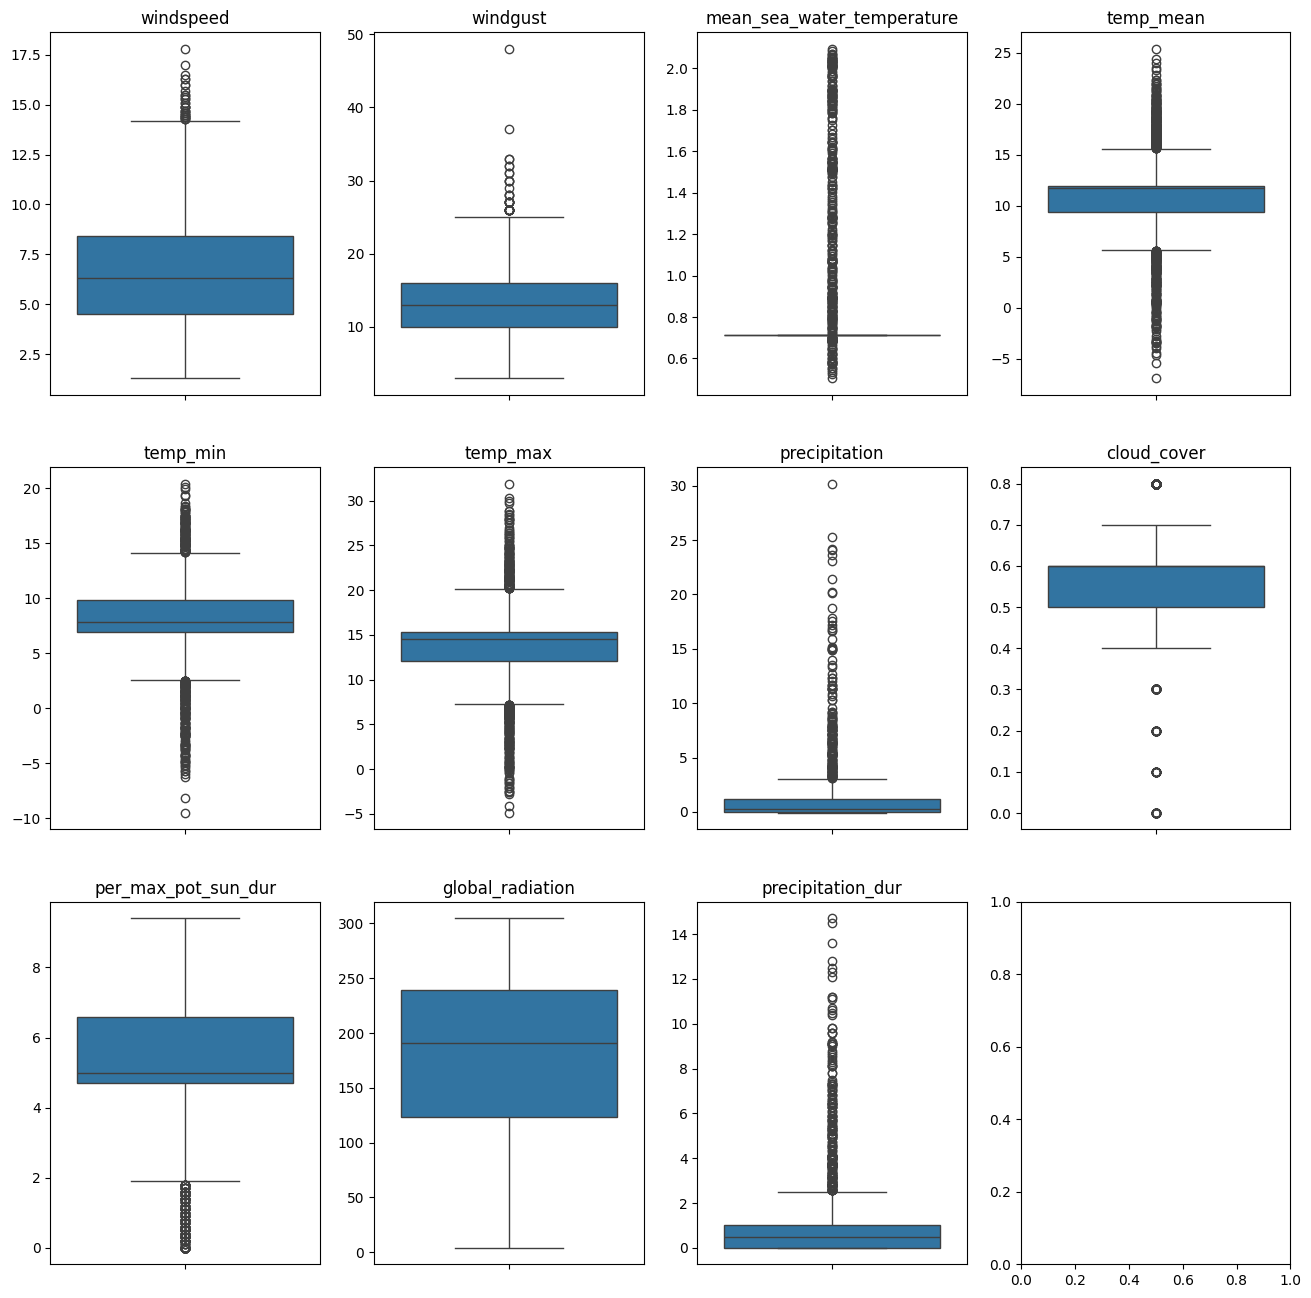

In [200]:
weather_cols = [
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

for col in weather_cols:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce') / 10

df_weather_small = df_weather[weather_cols]

weather_sample = df_weather[weather_cols].dropna().sample(
    n=min(2000, len(df_weather[weather_cols].dropna())),
    random_state=42
)

fig, axes = plt.subplots(3, 4, figsize=(16, 16))

axes = axes.flatten()

for i, col in enumerate(weather_cols):
    sns.boxplot(
        y=weather_sample[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')
    
plt.show()

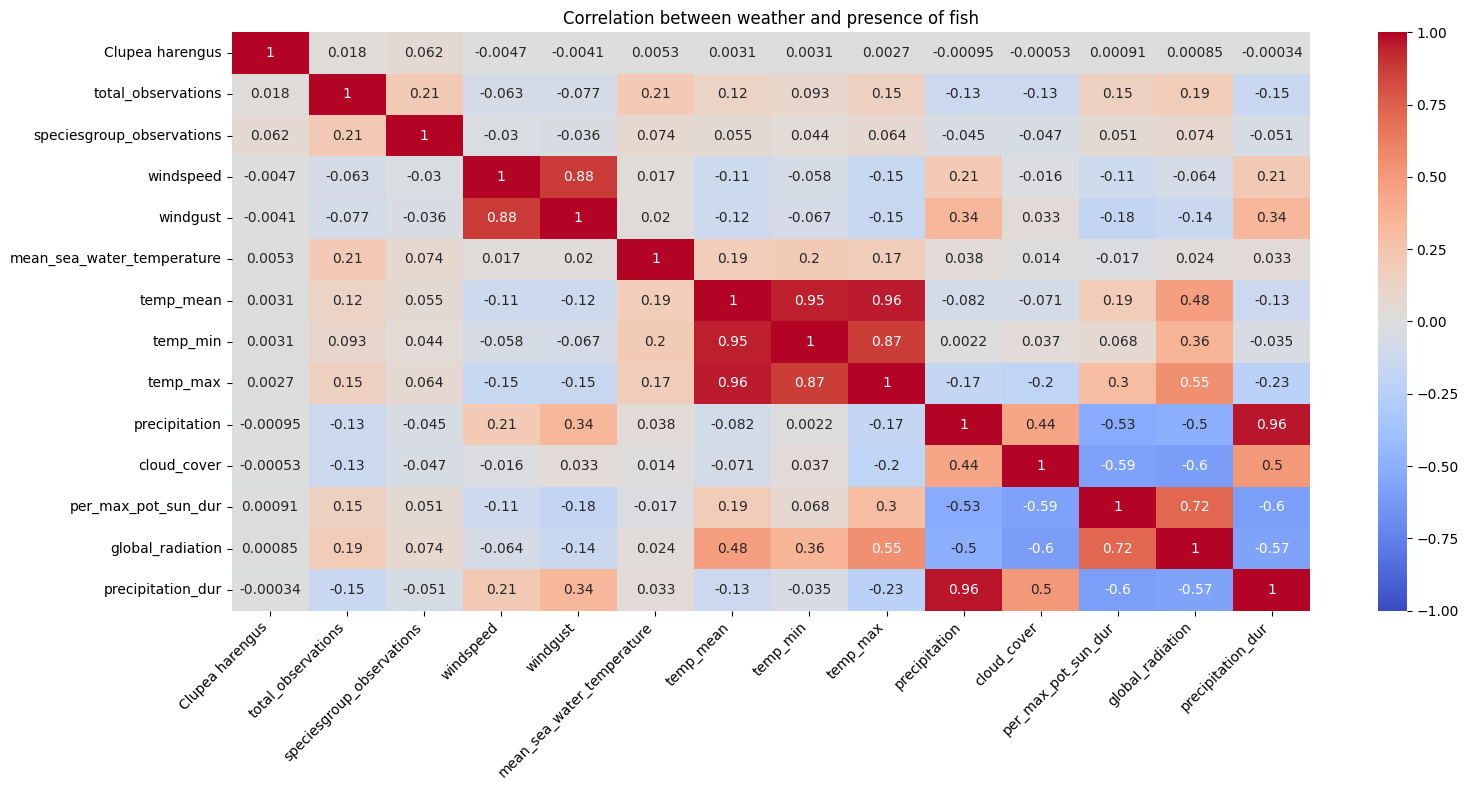

In [201]:


corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged[corr_cols]

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Correlation between weather and presence of fish')
plt.tight_layout()
plt.show()

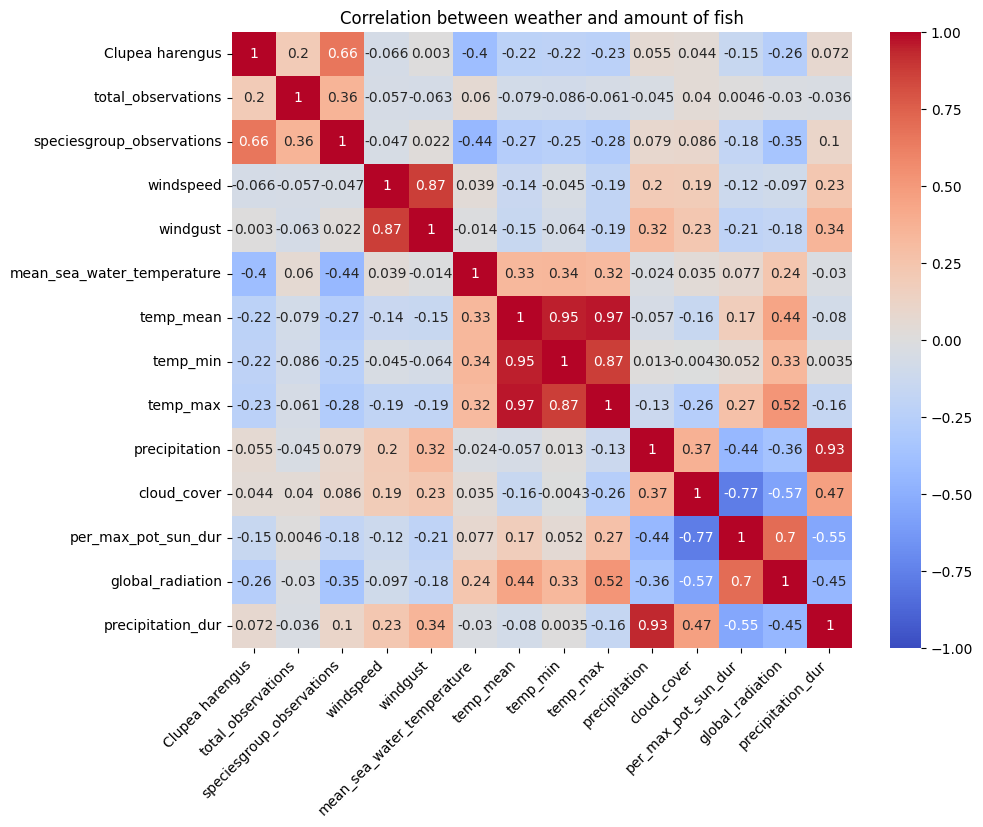

In [202]:


corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged_ch[corr_cols]

plt.figure(figsize=(10,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation between weather and amount of fish')
plt.show()

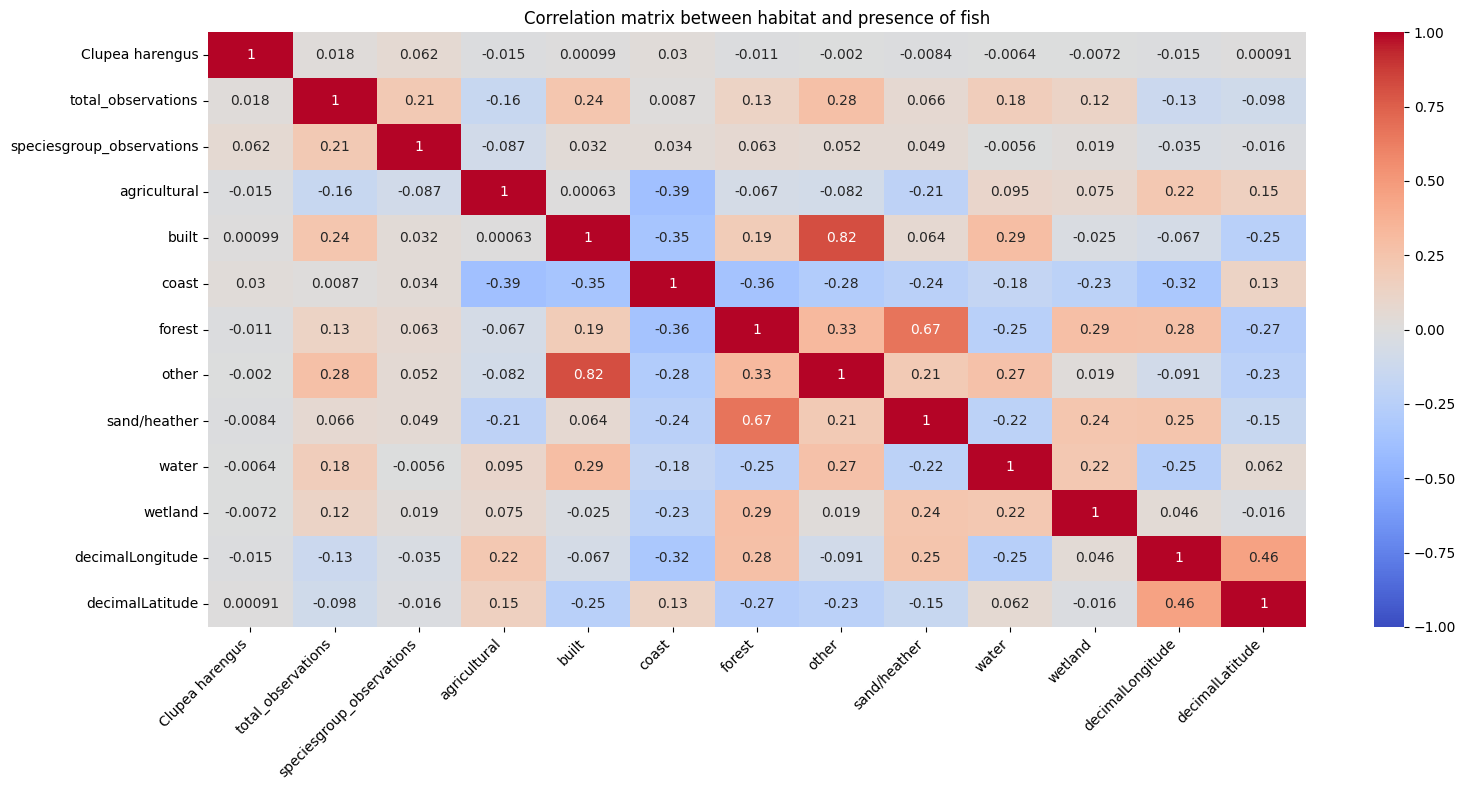

In [203]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland',
    'decimalLongitude',
    'decimalLatitude'
]

corr_df = df_merged[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation matrix between habitat and presence of fish')
plt.tight_layout()
plt.show()

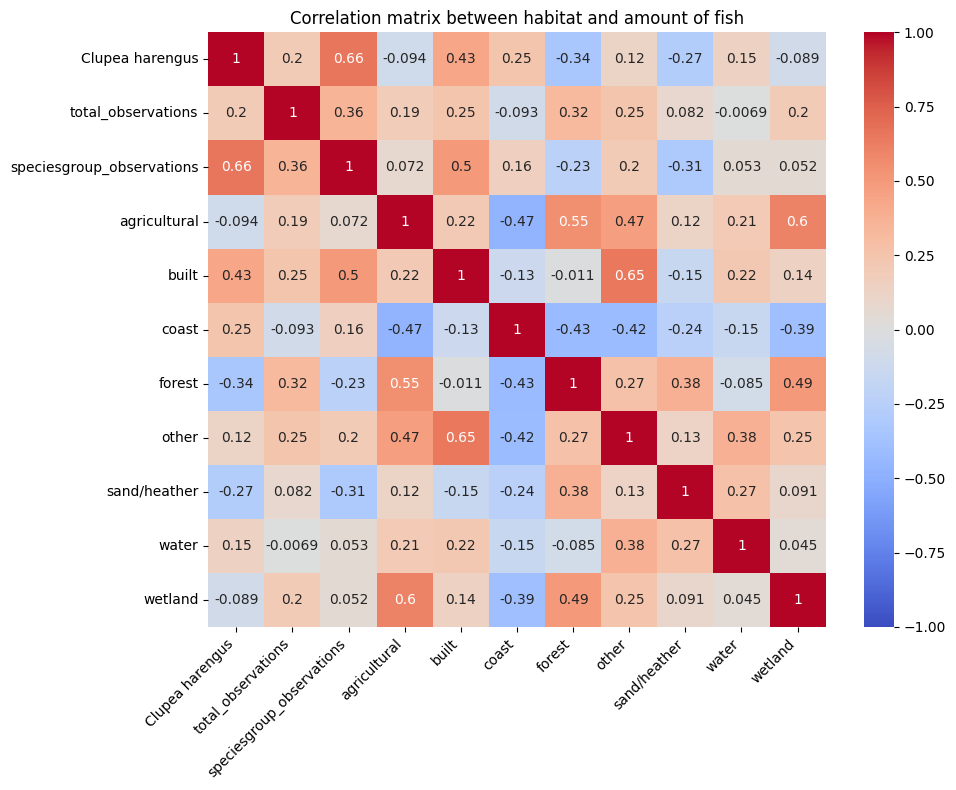

In [204]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

corr_df = df_merged_ch[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation matrix between habitat and amount of fish')
plt.tight_layout()
plt.show()

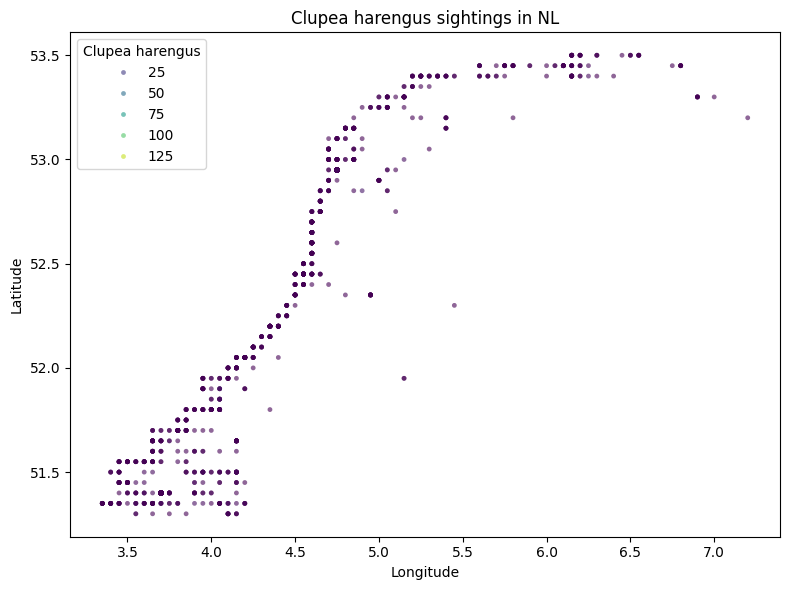

In [205]:
loc_sample = df_merged_ch[
    (df_merged_ch['Clupea harengus']>0) &
    (df_merged_ch['decimalLongitude'].between(3.0, 7.5)) &
    (df_merged_ch['decimalLatitude'].between(50.5, 53.7))
][['decimalLongitude', 'decimalLatitude', 'Clupea harengus']].dropna()

loc_sample = loc_sample.sample(
    n=min(2000, len(loc_sample)),
    random_state=69
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=loc_sample,
    x='decimalLongitude',
    y='decimalLatitude',
    hue='Clupea harengus',
    palette='viridis',
    s=12,
    alpha=0.6,
    linewidth=0
)

plt.title('Clupea harengus sightings in NL')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

No correlation

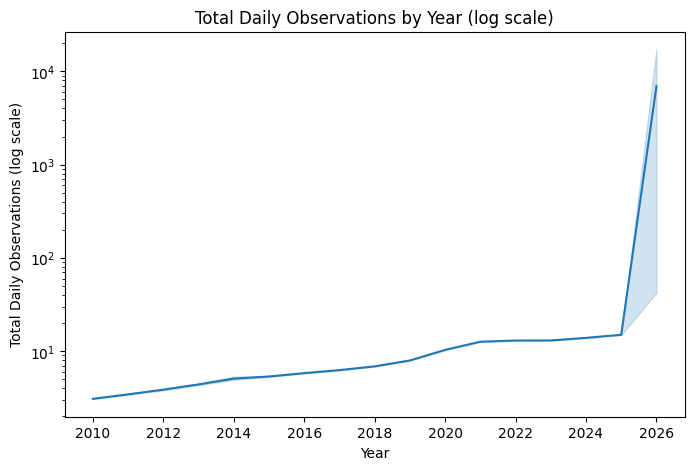

In [206]:
df_clupea['year'] = df_clupea['eventDate'].dt.year
year_counts = df_clupea['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_clupea,
    x='year',
    y='total_observations'
)

plt.yscale('log')

plt.title('Total Daily Observations by Year (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

No temporal bias

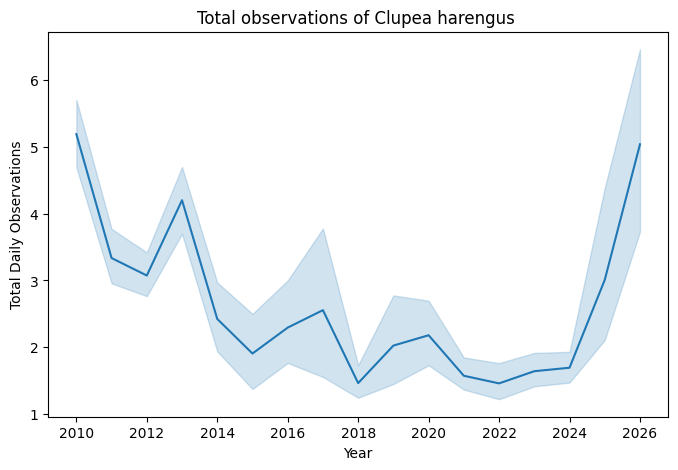

In [207]:
df_merged_ch['year'] = df_merged_ch['eventDate'].dt.year
year_counts = df_merged_ch['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_ch,
    x='year',
    y='Clupea harengus'
)

# plt.yscale('log')

plt.title('Total observations of Clupea harengus ')
plt.ylabel('Total Daily Observations')
plt.xlabel('Year')

plt.show()

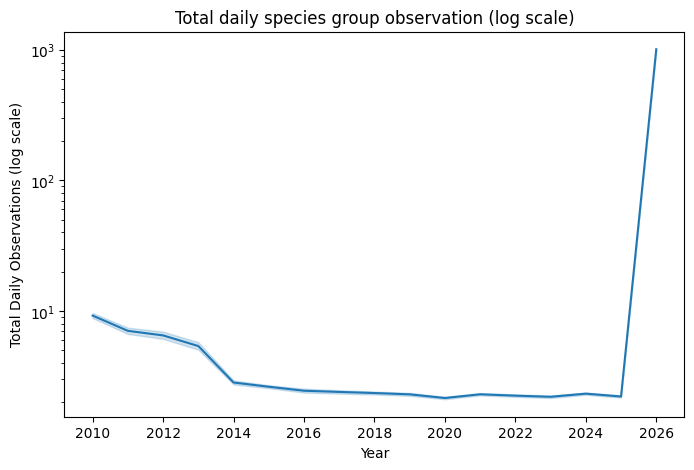

In [208]:
df_merged_so['year'] = df_merged_so['eventDate'].dt.year
year_counts = df_merged_so['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_so,
    x='year',
    y='speciesgroup_observations'
)

plt.yscale('log')

plt.title('Total daily species group observation (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

The yearly distribution of total daily observations shows a strong right-skewed pattern with numerous extreme outliers across all years. Observation magnitudes and variability appear to increase over time, particularly after 2018. This may reflect changes in ecological conditions, sampling intensity, or reporting practices. The logarithmic scale was necessary to visualize both small and extremely large observation counts simultaneously.

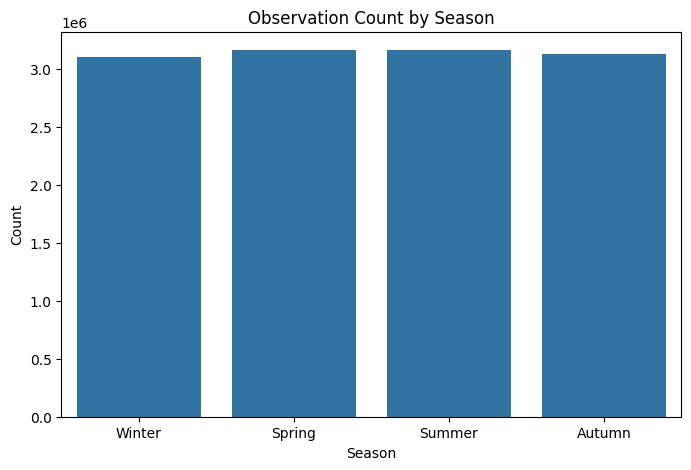

In [209]:
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

season_counts = df_clupea['season'].value_counts()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_counts[s] for s in season_order]
)

plt.title('Observation Count by Season')
plt.ylabel('Count')
plt.xlabel('Season')

plt.show()

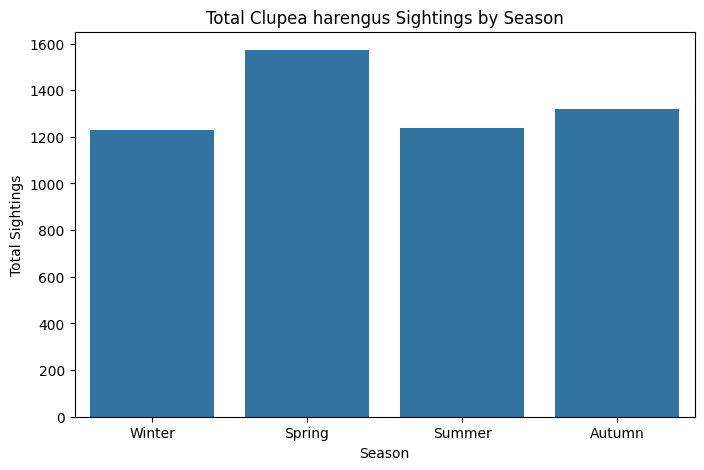

In [210]:
# Create season column
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Sum total herring sightings per season
season_sightings = df_clupea.groupby('season')['Clupea harengus'].sum()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_sightings[s] for s in season_order]
)

plt.title('Total Clupea harengus Sightings by Season')
plt.ylabel('Total Sightings')
plt.xlabel('Season')

plt.show()

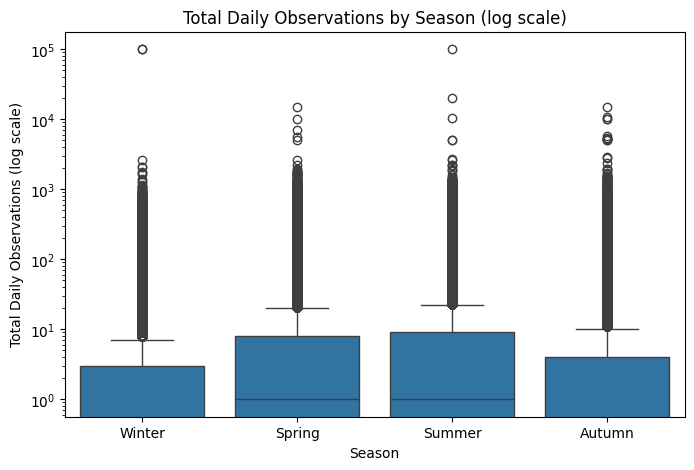

In [211]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clupea,
    x='season',
    y='total_observations'
)

plt.yscale('log')

plt.title('Total Daily Observations by Season (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Season')

plt.show()

The seasonal distributions of total observations appear highly right-skewed, with most values concentrated near zero and several extreme outliers present across all seasons. No strong seasonal imbalance is immediately visible, although summer contains some of the largest observation counts.

In [212]:
df_merged_ch.info()

<class 'pandas.DataFrame'>
Index: 2041 entries, 748653 to 12558785
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   decimalLatitude                2041 non-null   float64       
 1   decimalLongitude               2041 non-null   float64       
 2   eventDate                      2041 non-null   datetime64[us]
 3   total_observations             2040 non-null   float64       
 4   speciesgroup_observations      2041 non-null   int64         
 5   Clupea harengus                2041 non-null   float64       
 6   agricultural                   2015 non-null   float64       
 7   built                          2015 non-null   float64       
 8   coast                          2015 non-null   float64       
 9   forest                         2015 non-null   float64       
 10  other                          2015 non-null   float64       
 11  sand/heather            

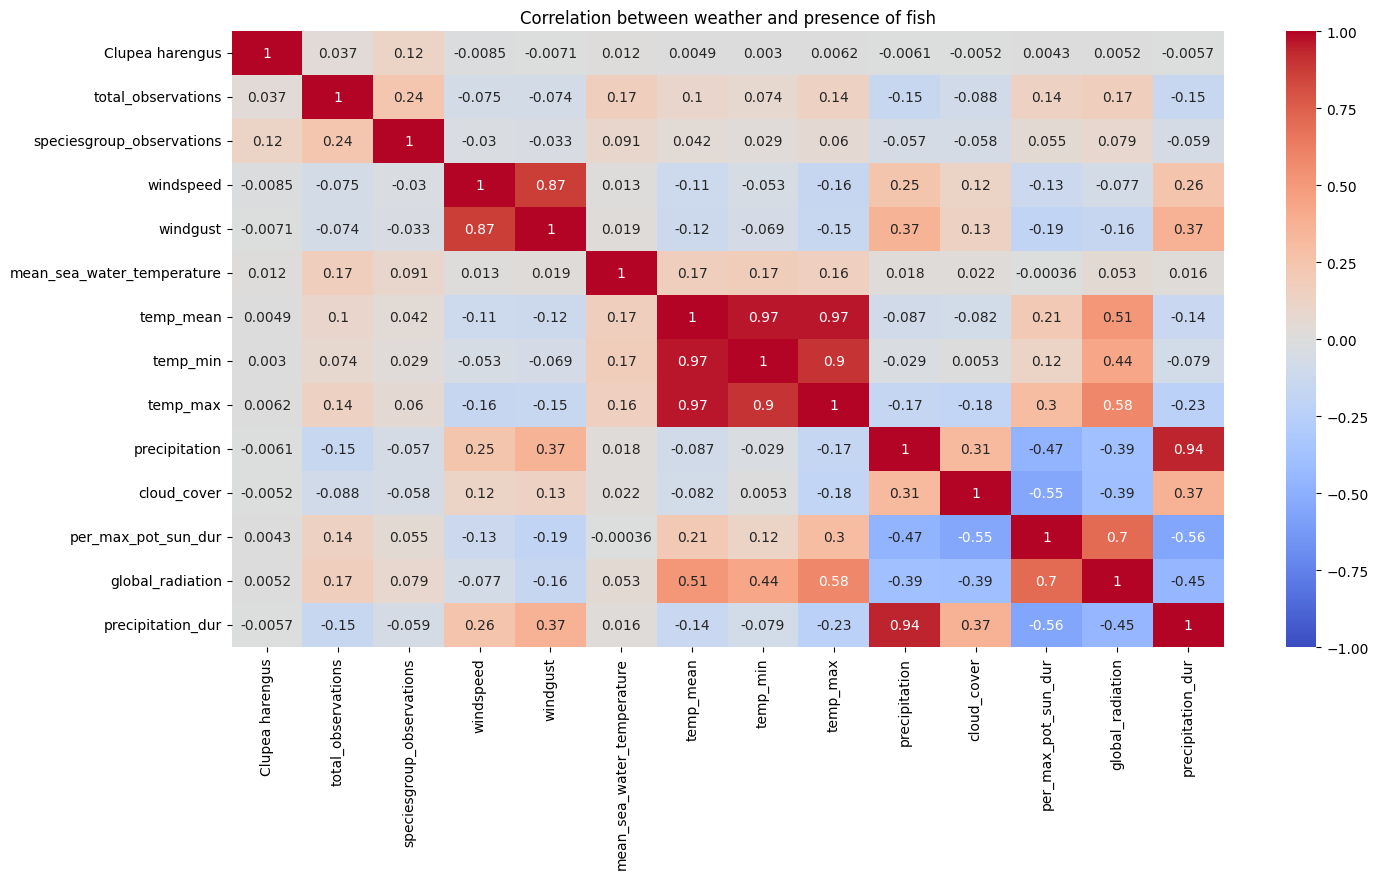

In [213]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged_coastal_marine[corr_cols]

plt.figure(figsize=(16,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation between weather and presence of fish')
plt.show()

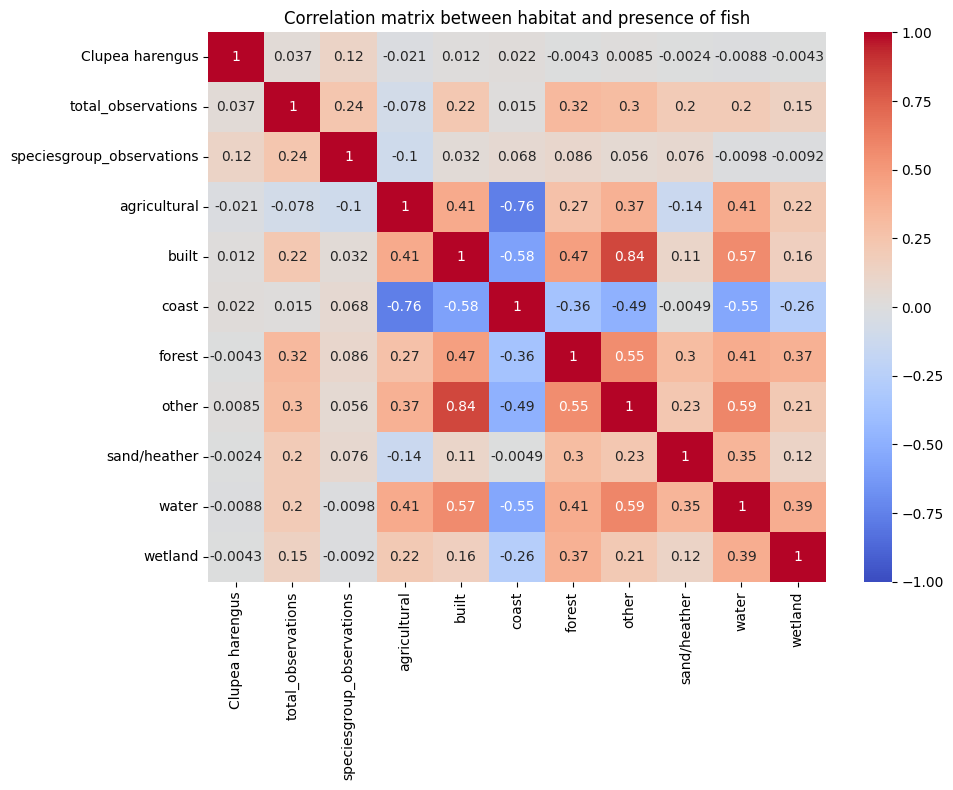

In [214]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

corr_df = df_merged_coastal_marine[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation matrix between habitat and presence of fish')
plt.tight_layout()
plt.show()

In [215]:
cols_to_drop = [
    'agricultural',
    'wetland',
    'windspeed',
    'windgust',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',
    'precipitation_dur',
    'vector_mean_direction_degrees',
    'vector_mean_windspeed',
    'Date',
    'station_distance_km',
    'Station',
    'nearest_station'
]

df_merged = df_merged.drop(columns=cols_to_drop, errors='ignore')
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 19 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   decimalLatitude             float64       
 1   decimalLongitude            float64       
 2   eventDate                   datetime64[us]
 3   total_observations          float64       
 4   speciesgroup_observations   int64         
 5   Clupea harengus             float64       
 6   built                       float64       
 7   coast                       float64       
 8   forest                      float64       
 9   other                       float64       
 10  sand/heather                float64       
 11  water                       float64       
 12  main_habitat                str           
 13  temp_mean                   float64       
 14  temp_min                    float64       
 15  temp_max                    float64       
 16  sun_dur                    

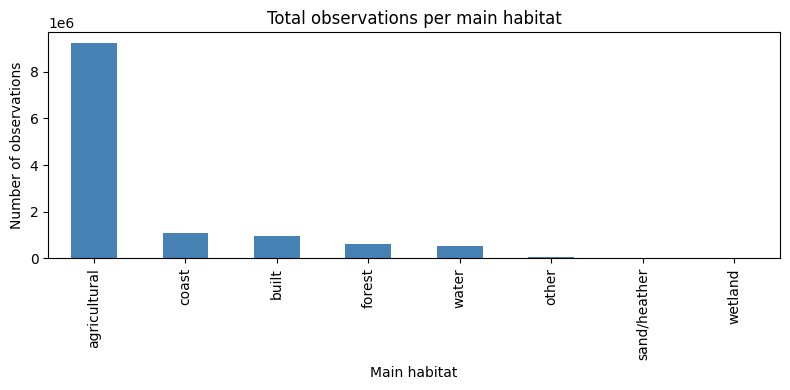

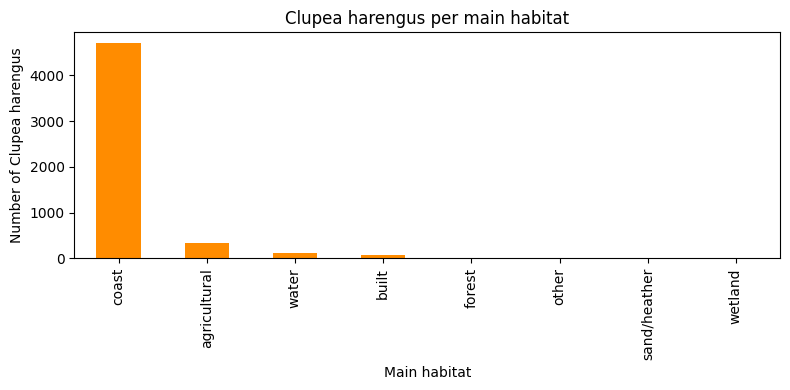

In [216]:
obs_per_habitat = (
    df_merged
        .groupby('main_habitat')
        .size()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
obs_per_habitat.plot(kind='bar', color='steelblue')
plt.ylabel('Number of observations')
plt.xlabel('Main habitat')
plt.title('Total observations per main habitat')
plt.tight_layout()
plt.show()

# 2) Total Clupea harengus per main habitat
ch_per_habitat = (
    df_merged
        .groupby('main_habitat')['Clupea harengus']
        .sum()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
ch_per_habitat.plot(kind='bar', color='darkorange')
plt.ylabel('Number of Clupea harengus')
plt.xlabel('Main habitat')
plt.title('Clupea harengus per main habitat')
plt.tight_layout()
plt.show()

### MODEL

In [217]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score


# 1) Build model dataframe and target
df_model = df_merged.copy()

# Binary target: presence (1) if > 0, else absence (0)
df_model['presence_ch'] = (df_model['Clupea harengus'] > 0).astype(int)

# 2) Date features
df_model['eventDate'] = pd.to_datetime(df_model['eventDate'])
df_model['year'] = df_model['eventDate'].dt.year
df_model['month'] = df_model['eventDate'].dt.month
df_model['dayofyear'] = df_model['eventDate'].dt.dayofyear

# 3) One-hot encode main_habitat
df_model = pd.get_dummies(df_model, columns=['main_habitat'], drop_first=True)

# 4) Full original dataset (unbalanced) to test on
df_full = df_model.copy()

# 5) Create balanced training set by downsampling majority class
present = df_full[df_full['presence_ch'] == 1]
absent  = df_full[df_full['presence_ch'] == 0]

ratio = 5  # e.g. up to 5x more absences than presences in training
absent_down = absent.sample(
    n=min(len(absent), ratio * len(present)),
    random_state=42
)

df_train_balanced = pd.concat([present, absent_down]).sample(frac=1, random_state=42)

# 6) Define feature columns
feature_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_full.columns if c.startswith('main_habitat_')]

# 7) Build X_train, y_train from balanced set
X_train = df_train_balanced[feature_cols]
y_train = df_train_balanced['presence_ch']

# 8) Build X_test, y_test from FULL (unbalanced) data
X_test = df_full[feature_cols]
y_test = df_full['presence_ch']

# 9) Train Random Forest on balanced data
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=3,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# 10) Evaluate on unbalanced full dataset
y_proba = rf.predict_proba(X_test)[:, 1]  # probability of presence

# Choose a higher threshold, e.g. 0.9
thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    f1_scores.append(f1)

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

y_pred_best = (y_proba >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

# 11) Optional: feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(20))

Best threshold: 0.99
Best F1 score: 0.5305105853051059
[[12556426      322]
 [    1186      852]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00  12556748
           1       0.73      0.42      0.53      2038

    accuracy                           1.00  12558786
   macro avg       0.86      0.71      0.77  12558786
weighted avg       1.00      1.00      1.00  12558786

coast                         0.335481
speciesgroup_observations     0.197102
main_habitat_coast            0.125512
total_observations            0.109826
decimalLongitude              0.082363
sand/heather                  0.022883
forest                        0.021872
year                          0.017880
built                         0.016842
water                         0.016049
other                         0.012753
decimalLatitude               0.011392
mean_sea_water_temperature    0.010266
temp_max                      0.004121
temp_mean                    

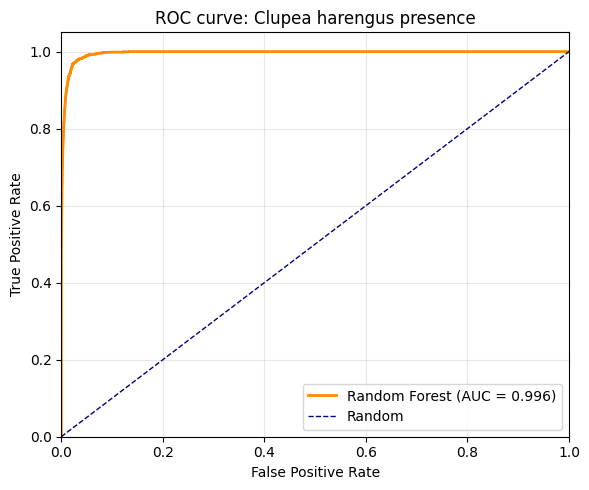

In [218]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1) Get predicted probabilities for the positive class
y_proba = rf.predict_proba(X_test)[:, 1]

# 2) Compute ROC curve points and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 3) Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve: Clupea harengus presence')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [219]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# === 1) Build model dataframe and target (same as before) ===
df_model = df_merged.copy()

df_model['presence_ch'] = (df_model['Clupea harengus'] > 0).astype(int)

df_model['eventDate'] = pd.to_datetime(df_model['eventDate'])
df_model['year'] = df_model['eventDate'].dt.year
df_model['month'] = df_model['eventDate'].dt.month
df_model['dayofyear'] = df_model['eventDate'].dt.dayofyear

df_model = pd.get_dummies(df_model, columns=['main_habitat'], drop_first=True)

df_full = df_model.copy()

present = df_full[df_full['presence_ch'] == 1]
absent  = df_full[df_full['presence_ch'] == 0]

ratio = 5
absent_down = absent.sample(
    n=min(len(absent), ratio * len(present)),
    random_state=42
)

df_train_balanced = pd.concat([present, absent_down]).sample(frac=1, random_state=42)

feature_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_full.columns if c.startswith('main_habitat_')]

X_train = df_train_balanced[feature_cols]
y_train = df_train_balanced['presence_ch']

X_test = df_full[feature_cols]
y_test = df_full['presence_ch']

# === 2) Train Decision Tree classifier ===
dt = DecisionTreeClassifier(
    max_depth=3,          # limit depth to reduce overfitting
    min_samples_leaf=20,  # avoid tiny leaves
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

from sklearn.metrics import f1_score

# === 3) Evaluate decision tree on full unbalanced dataset ===
y_proba = dt.predict_proba(X_test)[:, 1]  # <- use dt, not rf

thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    f1_scores.append(f1)

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

y_pred_best = (y_proba >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Best threshold: 0.93
Best F1 score: 0.04383861908349887
[[12487391    69357]
 [     438     1600]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00  12556748
           1       0.02      0.79      0.04      2038

    accuracy                           0.99  12558786
   macro avg       0.51      0.89      0.52  12558786
weighted avg       1.00      0.99      1.00  12558786



In [220]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

import numpy as np

# Start from your merged dataframe
df_reg = df_merged.copy()

# Keep only rows where herring is present
df_reg = df_reg[df_reg['Clupea harengus'] > 0].copy()

# Same date features as before
df_reg['eventDate'] = pd.to_datetime(df_reg['eventDate'])
df_reg['year'] = df_reg['eventDate'].dt.year
df_reg['month'] = df_reg['eventDate'].dt.month
df_reg['dayofyear'] = df_reg['eventDate'].dt.dayofyear

# One-hot encode habitat again (but on this subset)
df_reg = pd.get_dummies(df_reg, columns=['main_habitat'], drop_first=True)

feature_cols_reg = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_reg.columns if c.startswith('main_habitat_')]

X_reg = df_reg[feature_cols_reg]
y_reg = df_reg['Clupea harengus']   # continuous abundance where present

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=3
)

rf_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = rf_reg.predict(X_test_reg)

rmse = root_mean_squared_error(y_test_reg, y_pred_reg) #,squared=False)
mae = mean_absolute_error(y_test_reg, y_pred_reg)


print("RMSE:", rmse)
print("MAE:", mae)

# Optional: feature importances for abundance
importances_reg = pd.Series(rf_reg.feature_importances_, index=feature_cols_reg).sort_values(ascending=False)
print(importances_reg.head(15))

RMSE: 2.537861340976862
MAE: 1.2575598226985683
speciesgroup_observations     0.492197
total_observations            0.159364
year                          0.094211
mean_sea_water_temperature    0.054246
temp_min                      0.038120
forest                        0.034571
dayofyear                     0.029686
built                         0.025093
temp_mean                     0.018357
temp_max                      0.017821
global_radiation              0.014876
sun_dur                       0.006131
decimalLatitude               0.004296
coast                         0.003247
water                         0.002258
dtype: float64


5.844690966719493
5.0


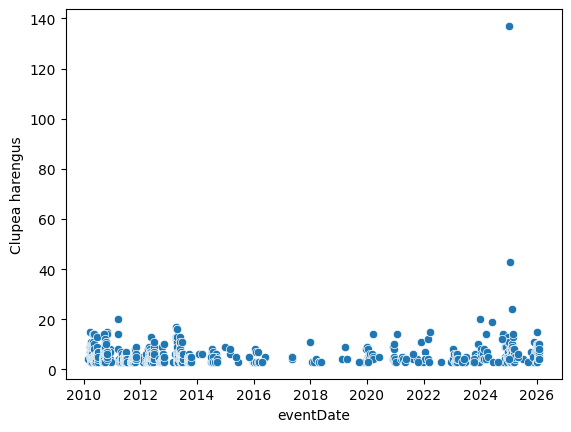

In [221]:
plot = df_merged_ch[df_merged_ch['Clupea harengus']>2]
sns.scatterplot(plot, y='Clupea harengus', x='eventDate')
print(plot['Clupea harengus'].mean())
print(plot['Clupea harengus'].median())

In [222]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.compose import TransformedTargetRegressor

import numpy as np

# Start from your merged dataframe
df_reg = df_merged.copy()

# Keep only rows where herring is present
df_reg = df_reg[df_reg['Clupea harengus'] > 0].copy()

# Same date features as before
df_reg['eventDate'] = pd.to_datetime(df_reg['eventDate'])
df_reg['year'] = df_reg['eventDate'].dt.year
df_reg['month'] = df_reg['eventDate'].dt.month
df_reg['dayofyear'] = df_reg['eventDate'].dt.dayofyear

# One-hot encode habitat again (but on this subset)
df_reg = pd.get_dummies(df_reg, columns=['main_habitat'], drop_first=True)

feature_cols_reg = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_reg.columns if c.startswith('main_habitat_')]

X_reg = df_reg[feature_cols_reg]
y_reg = df_reg['Clupea harengus']   # continuous abundance where present

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1
)

# 2. Wrap it to automatically log-transform y before fitting, and exp() after predicting
# We use log1p (log(1+x)) which is safe if there are any zeros, though you filtered for >0
rf_log = TransformedTargetRegressor(
    regressor=rf_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Fit and Predict
rf_log.fit(X_train_reg, y_train_reg)
y_pred_log = rf_log.predict(X_test_reg)

# 4. Evaluate in the ORIGINAL scale
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test_reg, y_pred_log))
print("RMSE:", root_mean_squared_error(y_test_reg, y_pred_log))
print("R²:", r2_score(y_test_reg, y_pred_log))

MAE: 1.1410874817167775
RMSE: 2.5511003370569583
R²: 0.38583968597437135


In [223]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Specify loss='poisson' for count data
hgb_poisson = HistGradientBoostingRegressor(
    loss='poisson',
    max_iter=200,
    max_depth=10,
    random_state=42
)

hgb_poisson.fit(X_train_reg, y_train_reg)
y_pred_pois = hgb_poisson.predict(X_test_reg)

print("MAE (Poisson):", mean_absolute_error(y_test_reg, y_pred_pois))
print("RMSE (Poisson):", root_mean_squared_error(y_test_reg, y_pred_pois))

MAE (Poisson): 1.2212156484410541
RMSE (Poisson): 2.581263670897554


In [224]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Specify loss='poisson' for count data
hgb_poisson = HistGradientBoostingRegressor(
    loss='poisson',
    max_iter=200,
    max_depth=10,
    random_state=42
)

hgb_poisson.fit(X_train_reg, y_train_reg)
y_pred_pois = hgb_poisson.predict(X_test_reg)

print("MAE (Poisson):", mean_absolute_error(y_test_reg, y_pred_pois))
print("RMSE (Poisson):", root_mean_squared_error(y_test_reg, y_pred_pois))

MAE (Poisson): 1.2212156484410541
RMSE (Poisson): 2.581263670897554


In [225]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    loss='squared_error',  # or 'poisson' for counts
    max_depth=10,
    max_iter=200,
    random_state=42
)

hgb.fit(X_train_reg, y_train_reg)
y_pred_hgb = hgb.predict(X_test_reg)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae_hgb  = mean_absolute_error(y_test_reg, y_pred_hgb)
rmse_hgb = root_mean_squared_error(y_test_reg, y_pred_hgb)
r2_hgb   = r2_score(y_test_reg, y_pred_hgb)

print("HistGB MAE:", mae_hgb)
print("HistGB RMSE:", rmse_hgb)
print("HistGB R²:", r2_hgb)

HistGB MAE: 1.3670927499263403
HistGB RMSE: 2.8848861473611653
HistGB R²: 0.2146124256466314
